# Plot Test Metrics for Your Model

This notebook saves figures for your model results.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

stages = ["W", "N1", "N2", "N3", "REM"]

test_accuracy = 0.751
test_mf1 = 0.671
test_kappa = 0.693

precision = [0.7284, 0.6127, 0.7859, 0.8186, 0.6738]
recall = [0.8012, 0.4521, 0.8294, 0.8613, 0.6108]
f1 = [0.7631, 0.5203, 0.8071, 0.8394, 0.6408]

confusion_matrix = np.array([
    [1787, 104, 112,  49,  79],
    [ 436, 728, 241,  54, 151],
    [ 118,  63, 4353, 402, 312],
    [  41,  11, 356, 3425, 144],
    [ 271, 282, 476, 213, 2783],
], dtype=float)

stage_output_path = "my_model_stage_metrics.png"
param_output_path = "my_model_accuracy_vs_parameters.png"


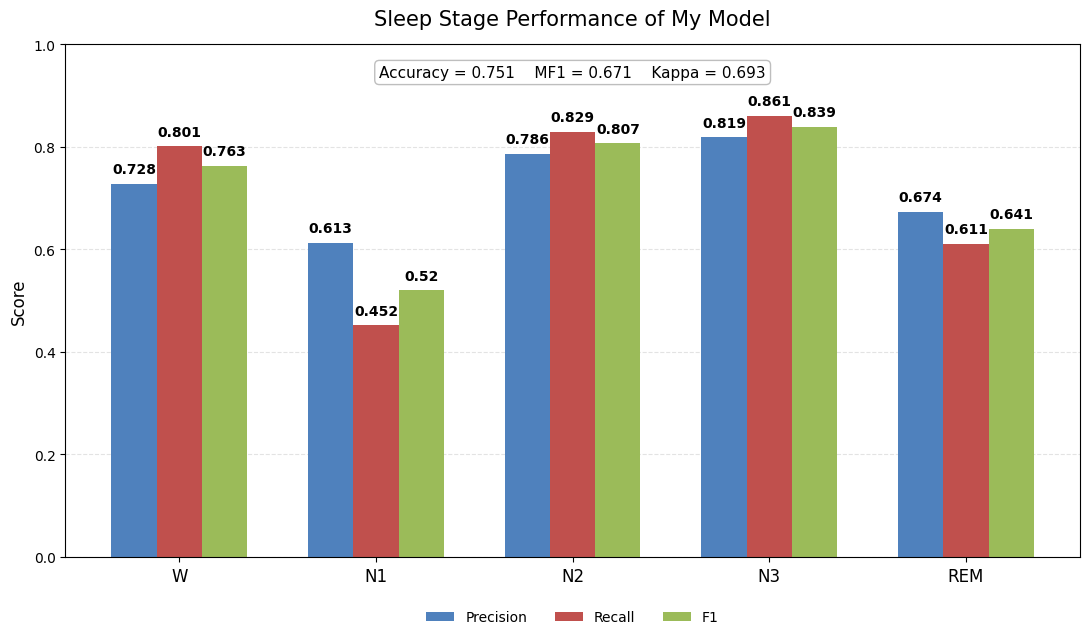

Saved plot to: my_model_stage_metrics.png


In [7]:
x = np.arange(len(stages))
width = 0.23

fig, ax = plt.subplots(figsize=(11, 6.5))
bars1 = ax.bar(x - width, precision, width, label="Precision", color="#4F81BD")
bars2 = ax.bar(x, recall, width, label="Recall", color="#C0504D")
bars3 = ax.bar(x + width, f1, width, label="F1", color="#9BBB59")

ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Sleep Stage Performance of My Model", fontsize=15, pad=14)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.08))

summary = f"Accuracy = {test_accuracy:.3f}    MF1 = {test_mf1:.3f}    Kappa = {test_kappa:.3f}"
ax.text(
    0.5,
    0.96,
    summary,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#bbbbbb", alpha=0.95),
)

def annotate_bars(axis, bars, offset=0.015):
    for bar in bars:
        height = bar.get_height()
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{height:.3f}".rstrip("0").rstrip("."),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

annotate_bars(ax, bars1)
annotate_bars(ax, bars2)
annotate_bars(ax, bars3)

plt.tight_layout()
plt.savefig(stage_output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {stage_output_path}")


In [8]:
print("Confusion matrix:")
print(confusion_matrix)


Confusion matrix:
[[1787.  104.  112.   49.   79.]
 [ 436.  728.  241.   54.  151.]
 [ 118.   63. 4353.  402.  312.]
 [  41.   11.  356. 3425.  144.]
 [ 271.  282.  476.  213. 2783.]]


## Exact Figure-Style Accuracy vs Parameters Plot

This matches the paper figure style closely. The custom model uses adaptive pooling, so its parameter count stays constant across enhancement lengths.

Right now you only have one measured accuracy point for your model: `n=5`, `accuracy=0.751`. The parameter count is calculated and reused for `n = 0, 5, 10, 15, 30`.

In [9]:
import sys
sys.path.insert(0, "/home/durgesh/Satyam/MRASleepNet")
from Model.custom import EpilepsyWithDilatedConv

enhancement_lengths = [0, 5, 10, 15, 30]

# Use np.nan for enhancement lengths you have not measured yet.
my_accuracy = [np.nan, 0.751, np.nan, np.nan, np.nan]

model = EpilepsyWithDilatedConv()
param_count_m = sum(p.numel() for p in model.parameters()) / 1_000_000
my_params_m = [param_count_m for _ in enhancement_lengths]

print(f"Custom model parameters: {param_count_m:.3f}M for all enhancement lengths")


Custom model parameters: 0.456M for all enhancement lengths


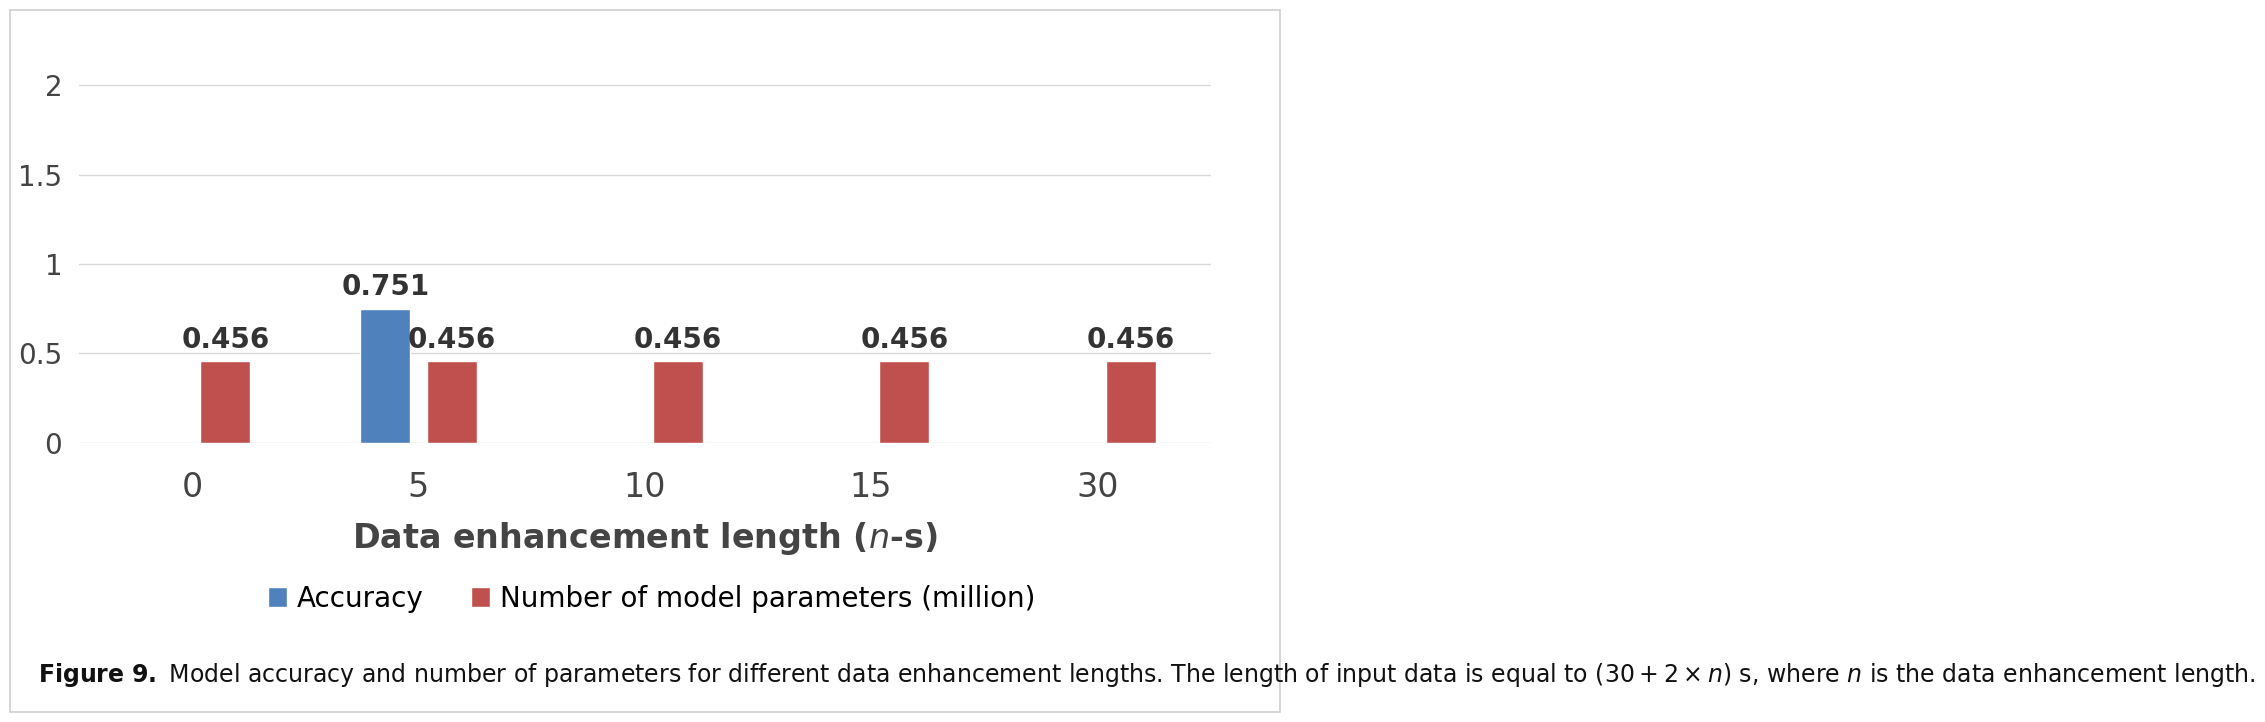

Saved plot to: my_model_accuracy_vs_parameters.png


In [10]:
x = np.arange(len(enhancement_lengths))
bar_width = 0.22

fig = plt.figure(figsize=(13.8, 7.8), facecolor="white")
ax = fig.add_axes([0.085, 0.37, 0.82, 0.47])

bars_acc = []
bars_param = []
for i, (acc, prm) in enumerate(zip(my_accuracy, my_params_m)):
    if not np.isnan(acc):
        bars_acc.extend(ax.bar(i - bar_width / 1.5, acc, width=bar_width, color="#4F81BD", edgecolor="white"))
    if not np.isnan(prm):
        bars_param.extend(ax.bar(i + bar_width / 1.5, prm, width=bar_width, color="#C0504D", edgecolor="white"))

ax.set_xlim(-0.5, len(enhancement_lengths) - 0.5)
ax.set_ylim(0, 2.05)
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in enhancement_lengths], fontsize=24, color="#444444")
ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0])
ax.set_yticklabels(["0", "0.5", "1", "1.5", "2"], fontsize=20, color="#444444")
ax.tick_params(axis="x", pad=20, length=0)
ax.tick_params(axis="y", pad=12, length=0)

ax.grid(axis="y", color="#d9d9d9", linewidth=1.0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel(r"Data enhancement length ($n$-s)", fontsize=24, fontweight="bold", labelpad=12, color="#444444")

def add_value_labels(bars, dy):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + dy,
            f"{height:.3f}".rstrip("0").rstrip("."),
            ha="center",
            va="bottom",
            fontsize=20,
            fontweight="bold",
            color="#333333",
        )

add_value_labels(bars_acc, 0.04)
add_value_labels(bars_param, 0.04)

legend_handles = [
    Patch(facecolor="#4F81BD", edgecolor="white", label="Accuracy"),
    Patch(facecolor="#C0504D", edgecolor="white", label="Number of model parameters (million)"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.12),
    ncol=2,
    frameon=False,
    fontsize=20,
    handlelength=0.7,
    handletextpad=0.35,
    columnspacing=1.7,
)

caption = (
    r"$\bf{Figure\ 9.}$ Model accuracy and number of parameters for different data enhancement lengths. "
    r"The length of input data is equal to $(30 + 2 \times n)$ s, where $n$ is the data enhancement length."
)
fig.text(0.055, 0.055, caption, ha="left", va="bottom", fontsize=17, color="#111111")

border = Rectangle((0.035, 0.025), 0.92, 0.9, transform=fig.transFigure, fill=False, linewidth=1.2, edgecolor="#cfcfcf")
fig.add_artist(border)

fig.savefig(param_output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {param_output_path}")


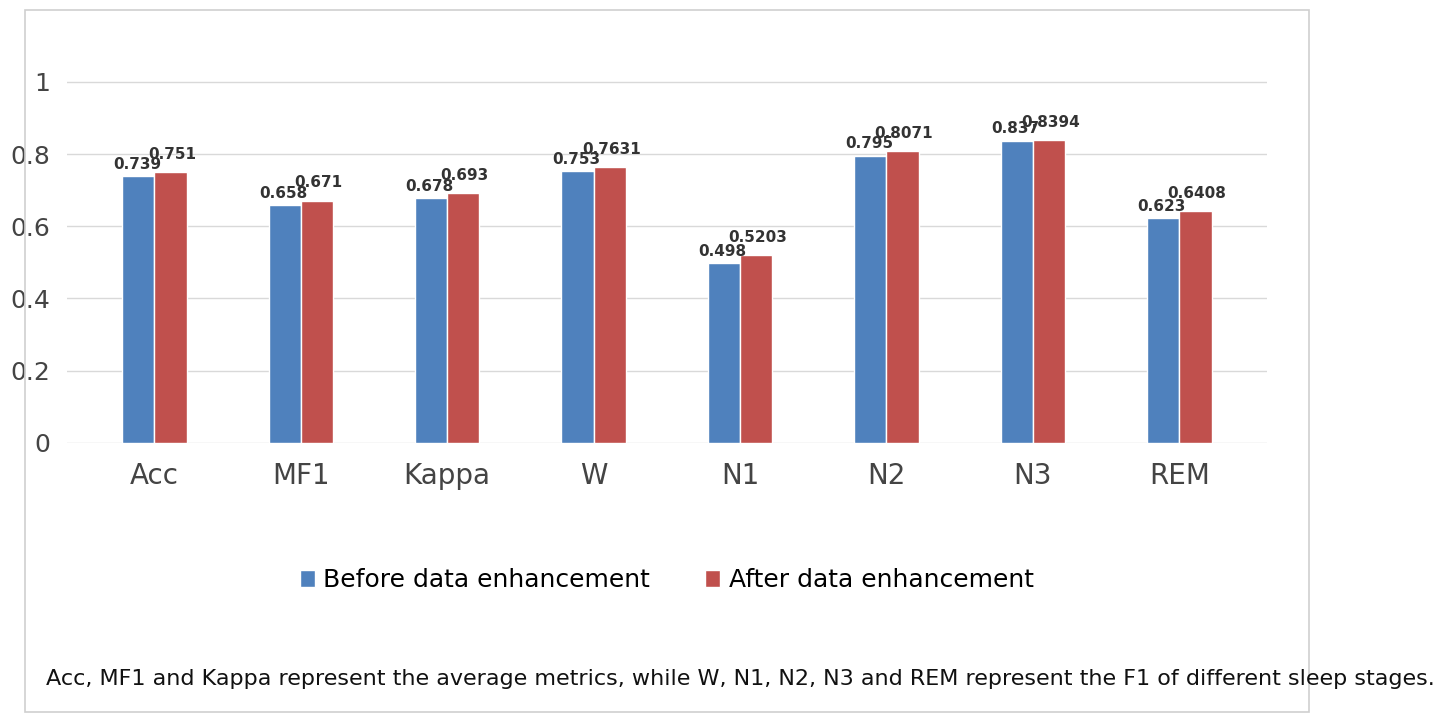

Saved plot to: before_after_data_enhancement_fixed.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

# Metrics order:
# [Acc, MF1, Kappa, W_F1, N1_F1, N2_F1, N3_F1, REM_F1]
labels = ["Acc", "MF1", "Kappa", "W", "N1", "N2", "N3", "REM"]

before_vals = [
    0.739,  # Acc
    0.658,  # MF1
    0.678,  # Kappa
    0.753,  # W F1
    0.498,  # N1 F1
    0.795,  # N2 F1
    0.837,  # N3 F1
    0.623,  # REM F1
]

after_vals = [
    0.751,   # Acc
    0.671,   # MF1
    0.693,   # Kappa
    0.7631,  # W F1
    0.5203,  # N1 F1
    0.8071,  # N2 F1
    0.8394,  # N3 F1
    0.6408,  # REM F1
]

output_path = "before_after_data_enhancement_fixed.png"

x = np.arange(len(labels))
bar_width = 0.22

fig = plt.figure(figsize=(13.8, 7.8), facecolor="white")
ax = fig.add_axes([0.065, 0.37, 0.87, 0.50])

bars_before = ax.bar(
    x - bar_width / 2,
    before_vals,
    width=bar_width,
    color="#4F81BD",
    edgecolor="white"
)
bars_after = ax.bar(
    x + bar_width / 2,
    after_vals,
    width=bar_width,
    color="#C0504D",
    edgecolor="white"
)

ax.set_xlim(-0.6, len(labels) - 0.4)
ax.set_ylim(0, 1.08)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=20, color="#444444")
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.set_yticklabels(
    [f"{v:.1f}".rstrip("0").rstrip(".") for v in np.arange(0, 1.01, 0.2)],
    fontsize=18,
    color="#444444"
)
ax.tick_params(axis="x", pad=14, length=0)
ax.tick_params(axis="y", pad=12, length=0)

ax.grid(axis="y", color="#d9d9d9", linewidth=1.0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

def add_value_labels(bars, y_offset=0.015, x_shift=0.0, fontsize=12):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2 + x_shift,
            h + y_offset,
            f"{h:.4f}".rstrip("0").rstrip("."),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            fontweight="bold",
            color="#333333",
        )

# Give left and right bars slightly different offsets
add_value_labels(bars_before, y_offset=0.012, x_shift=-0.01, fontsize=11)
add_value_labels(bars_after, y_offset=0.028, x_shift=0.01, fontsize=11)

legend_handles = [
    Patch(facecolor="#4F81BD", edgecolor="white", label="Before data enhancement"),
    Patch(facecolor="#C0504D", edgecolor="white", label="After data enhancement"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.15),
    ncol=2,
    frameon=False,
    fontsize=18,
    handlelength=0.6,
    handletextpad=0.35,
    columnspacing=2.2,
)

caption = (
    "Acc, MF1 and Kappa represent the average metrics, while W, N1, N2, N3 "
    "and REM represent the F1 of different sleep stages."
)
fig.text(0.05, 0.055, caption, ha="left", va="bottom", fontsize=16, color="#111111")

border = Rectangle(
    (0.035, 0.025), 0.93, 0.9,
    transform=fig.transFigure,
    fill=False,
    linewidth=1.2,
    edgecolor="#cfcfcf"
)
fig.add_artist(border)

fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {output_path}")